# Feature engineering — les bases

## Qu'est-ce qu'on va faire dans ce notebook ?

On a vu dans le chapitre précédent que **les données brutes ne suffisent pas** à un modèle de machine learning. Ce notebook montre **en pratique** les gestes essentiels de feature engineering pour préparer un dataset typique (le Titanic) à être utilisé par un algorithme de classification.

> **L'objectif n'est pas d'obtenir le meilleur score possible** — c'est de mettre en place un **pipeline propre et réutilisable** qui fait correctement le travail de base : imputation des valeurs manquantes, encodage des variables catégorielles, combinaison de plusieurs transformations, et déploiement en production.

### Le plan

1. **Nettoyage initial** (*data cleaning*) : homogénéisation des noms, types, formats.
2. **Split train/test** : isoler le test **avant** toute analyse, pour éviter le data leakage.
3. **Imputation des valeurs manquantes** : médiane pour les numériques, mode pour les catégorielles.
4. **Encodage des variables catégorielles** : transformer `sex`, `embarked` en nombres utilisables.
5. **Pipeline unifié** : combiner toutes les étapes avec `ColumnTransformer` + `Pipeline`.
6. **Entraînement et comparaison** de plusieurs modèles (régression logistique, Random Forest, XGBoost).
7. **Baseline** : s'assurer qu'on fait mieux qu'un prédicteur bête.
8. **Déploiement** : sérialiser le pipeline et le modèle pour la production.

## Data cleaning — mise en forme des données

C'est la **phase initiale** du feature engineering. On cherche à rendre les données :

- **conformes aux règles de nommage de l'entreprise** (noms de colonnes, valeurs de catégories : `"Sexe"` vs `"sex"`, `"M"` vs `"Male"` vs `"male"`...) ;
- **homogènes** (même format partout : dates au même format, unités cohérentes, encodage texte uniforme) ;

![uniformize-features](../../images/uniformize-features.png)

- **compatibles avec les algorithmes** :
  - toutes les valeurs **renseignées** (pas de `NaN`) ;
  - toutes les valeurs **numériques** (les catégories en texte seront encodées plus tard).

> **C'est souvent l'étape la plus longue et la moins gratifiante** — mais celle qui évite 80% des bugs. Passer du temps ici, c'est du temps gagné sur le debug plus tard.

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style('whitegrid')

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [2]:
titanic = pd.read_csv("../../data/titanic.csv")
titanic1 = titanic.drop("survived", axis=1)
survived = titanic["survived"]

In [3]:
titanic1.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [4]:
survived.shape

(1309,)

## Création des jeux d'apprentissage et de test

**⚠️ L'ordre des opérations est critique :** on splitte train/test **AVANT** tout feature engineering. Sinon, on risque le **data leakage** — des informations du test « fuitent » vers le train via les transformations (moyennes d'imputation, seuils de scaling, proportions d'encodage...).

> **L'analogie à garder en tête :** le jeu de test, c'est l'**examen final**. L'EDA et le feature engineering, c'est la **préparation à l'examen**. Si tu regardes les questions de l'examen avant de préparer tes révisions, ton 20/20 ne veut plus rien dire. Le test doit **rester scellé** jusqu'à la toute fin.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    titanic1,
    survived, 
    test_size=0.25,
    random_state=2
)
y_train = y_train.values.astype(int)
y_test = y_test.values.astype(int)

In [6]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 981 entries, 1195 to 1192
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     981 non-null    int64  
 1   name       981 non-null    object 
 2   sex        981 non-null    object 
 3   age        789 non-null    float64
 4   sibsp      981 non-null    int64  
 5   parch      981 non-null    int64  
 6   ticket     981 non-null    object 
 7   fare       980 non-null    float64
 8   cabin      225 non-null    object 
 9   embarked   980 non-null    object 
 10  boat       373 non-null    object 
 11  body       89 non-null     float64
 12  home.dest  568 non-null    object 
dtypes: float64(3), int64(3), object(7)
memory usage: 107.3+ KB


In [7]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 328 entries, 886 to 916
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     328 non-null    int64  
 1   name       328 non-null    object 
 2   sex        328 non-null    object 
 3   age        257 non-null    float64
 4   sibsp      328 non-null    int64  
 5   parch      328 non-null    int64  
 6   ticket     328 non-null    object 
 7   fare       328 non-null    float64
 8   cabin      70 non-null     object 
 9   embarked   327 non-null    object 
 10  boat       113 non-null    object 
 11  body       32 non-null     float64
 12  home.dest  177 non-null    object 
dtypes: float64(3), int64(3), object(7)
memory usage: 35.9+ KB


## Data cleaning — traitement des valeurs manquantes

En pratique, **les valeurs manquantes (NaN) sont partout**. Un capteur qui a planté, un formulaire pas rempli, une fusion de fichiers incomplète, une API qui a timeouté... Il faut les traiter sous peine que la plupart des algorithmes scikit-learn plantent.

**Deux grandes stratégies :**

1. **Supprimer** les lignes (ou les colonnes) qui en contiennent.
2. **Imputer** : remplacer par une valeur « raisonnable » (moyenne, médiane, mode, valeur prédite, valeur sentinelle...).

On va voir les deux cas dans la suite — et pourquoi **l'imputation est presque toujours préférable**.

**Diagnostic rapide** : `info()` nous montre que `age`, `fare` et `embarked` ont des valeurs manquantes dans le jeu de train.

**Décision par colonne** :

- **`fare`** et **`embarked`** : très peu de NaN (1 ou 2 lignes). On *pourrait* penser à supprimer ces lignes.
- **`age`** : il manque **beaucoup** de valeurs (environ 20%). Hors de question de supprimer autant de lignes — on va **imputer**, en affectant par exemple la médiane.

> **Pourquoi ne pas supprimer « juste les quelques lignes » ?**
>
> C'est tentant — 1 ou 2 lignes manquantes sur 1000, ça paraît anodin. Mais cela signifie qu'**à l'avenir**, si un nouveau passager a une valeur manquante dans `fare` ou `embarked`, **on ne pourra pas faire de prédiction pour lui**. Le modèle ne saura pas quoi faire.
>
> En production, la **tolérance aux valeurs manquantes** est essentielle. Un modèle qui fonctionne seulement si **toutes** les colonnes sont remplies est un modèle fragile. On préfère donc adopter une **approche plus générale** et toujours imputer, même pour les colonnes où il manque très peu de données.
>
> **Règle pratique :** *toujours avoir une stratégie d'imputation pour chaque colonne*, même si elle semble complète sur le train. Ça rend le pipeline robuste et prêt pour la production.

### Imputation des colonnes numériques

On utilise un [`SimpleImputer`](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html) avec `strategy='median'` : les NaN sont remplacés par la **médiane** de chaque colonne (calculée sur le train uniquement).

**Pourquoi la médiane et pas la moyenne ?** Parce que la médiane est **robuste aux outliers**. Rappelle-toi du `fare` du Titanic : quelques billets très chers tirent la moyenne vers le haut sans être représentatifs. La médiane reflète mieux *« la valeur typique »*.

> **On inclut les colonnes ordinales** (`pclass`) dans cette imputation : elles sont déjà encodées en numérique (1, 2, 3) et la médiane d'une variable ordinale a du sens (c'est la catégorie du milieu).

In [8]:
from sklearn.impute import SimpleImputer

numeric_cols = ["pclass", "age", "sibsp", "parch", "fare"]
X_train_num = X_train[numeric_cols]
median_imputer = SimpleImputer(missing_values=np.nan, strategy='median')
median_imputer.fit(X_train_num)
X_train_num = pd.DataFrame(median_imputer.transform(X_train_num),
                           columns=numeric_cols)
X_train_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pclass  981 non-null    float64
 1   age     981 non-null    float64
 2   sibsp   981 non-null    float64
 3   parch   981 non-null    float64
 4   fare    981 non-null    float64
dtypes: float64(5)
memory usage: 38.4 KB


**Vérifier l'effet de l'imputation** est un réflexe sain. On compare la distribution de `age` **avant** et **après** imputation avec deux histogrammes côte à côte.

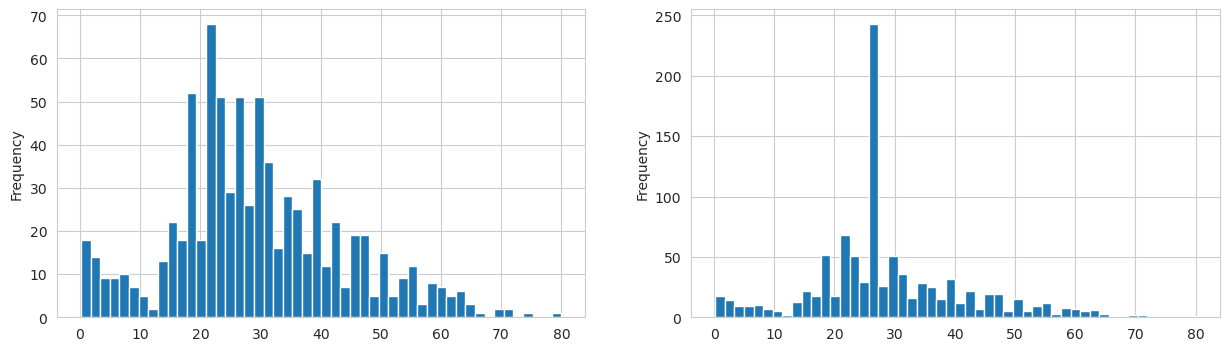

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
X_train["age"].plot(kind="hist", bins=50, ax=ax1)
X_train_num["age"].plot(kind="hist", bins=50, ax=ax2);

**Observation attendue :** on voit une **surreprésentation de la médiane** (un pic démesurément grand à la valeur médiane). C'est le principal défaut de l'imputation par constante : tous les NaN convergent vers la même valeur, ce qui crée un artefact visible dans la distribution.

> **🎯 Conséquences en ML :**
> - Le pic artificiel peut **fausser les analyses de distribution** ultérieures.
> - Il peut **biaiser certains algorithmes** qui raisonnent en termes de densité (KDE, GMM).
> - Un arbre de décision, lui, s'en sort bien — il va juste créer une branche *« age == valeur-médiane ? »* qui correspondra aux imputés.
>
> **Alternatives plus sophistiquées** (vues plus tard dans le chapitre 07) :
> - `IterativeImputer` : prédit la valeur manquante en utilisant les autres colonnes comme features (régression).
> - `KNNImputer` : prend la moyenne des $k$ voisins les plus proches.
> - **Ajouter une colonne indicatrice** `age_was_missing` (booléen) pour laisser le modèle savoir *« cette valeur était manquante »* — utile si la présence de NaN elle-même est informative.

### Imputation des colonnes catégorielles

Pour les colonnes catégorielles (`sex`, `embarked`), la médiane ne marche pas (qu'est-ce que la « médiane » entre `male` et `female` ?). On utilise à la place `strategy='most_frequent'` : les NaN sont remplacés par la **valeur la plus fréquente** (le **mode**).

> **Pourquoi le mode ?** Parce qu'en l'absence d'information, c'est le choix le plus probable. Si 75% des passagers ont embarqué à Southampton, imputer Southampton pour un passager dont on ne connaît pas le port est la meilleure « estimation naïve » qu'on puisse faire.
>
> **Limites :** comme pour la médiane sur les numériques, on crée une sur-représentation du mode. Si c'est problématique, on peut utiliser `strategy='constant'` avec une valeur sentinelle comme `"missing"` pour créer une catégorie « manquant » à part, que les modèles à base d'arbres peuvent très bien exploiter.

In [10]:
categorical_cols = ["sex", "embarked"]
X_train_cat = X_train[categorical_cols]
most_frequent_imputer = SimpleImputer(missing_values=np.nan,
                                      strategy='most_frequent')
most_frequent_imputer.fit(X_train_cat)
X_train_cat = pd.DataFrame(most_frequent_imputer.transform(X_train_cat),
                           columns=categorical_cols)
X_train_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sex       981 non-null    object
 1   embarked  981 non-null    object
dtypes: object(2)
memory usage: 15.5+ KB


### Combinaison des transformations avec ColumnTransformer

Jusqu'ici on a appliqué les imputations **colonne par colonne**, à la main. Peu pratique. Le [`ColumnTransformer`](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html) permet d'**appliquer des transformations différentes à des colonnes différentes**, le tout dans un seul objet scikit-learn.

> **Mental model :** `ColumnTransformer`, c'est comme une **orchestration de tapis roulants** : chaque colonne passe par le traitement approprié (numérique → imputation médiane, catégoriel → imputation mode), et tout ressort dans le même tableau final, colonnes réassemblées dans le bon ordre.

**Points clés du code ci-dessous :**
- On définit chaque « transformer » avec une **liste `(nom, transformer, colonnes)`**.
- Le paramètre **`remainder='drop'`** exclut les colonnes non mentionnées (sinon on peut utiliser `'passthrough'` pour les laisser inchangées).
- Après `fit`, le `ColumnTransformer` connaît les statistiques (médianes, modes) **apprises sur le train** et peut les réappliquer au test avec `transform`.

In [11]:
from sklearn.compose import ColumnTransformer

column_trans = ColumnTransformer(
    [
        ('numerical', median_imputer, numeric_cols),
        ('categorical', most_frequent_imputer, categorical_cols),
    ], remainder='drop', verbose_feature_names_out=False
)
column_trans.fit(X_train)

ColumnTransformer(transformers=[('numerical', SimpleImputer(strategy='median'),
                                 ['pclass', 'age', 'sibsp', 'parch', 'fare']),
                                ('categorical',
                                 SimpleImputer(strategy='most_frequent'),
                                 ['sex', 'embarked'])],
                  verbose_feature_names_out=False)

In [12]:
X_train_trans = pd.DataFrame(column_trans.transform(X_train), columns=column_trans.get_feature_names_out())
X_train_trans.head()

,pclass,age,sibsp,parch,fare,sex,embarked
0,3.0,27.0,0.0,0.0,7.75,male,Q
1,3.0,37.0,2.0,0.0,7.925,male,S
2,1.0,60.0,0.0,0.0,26.55,male,S
3,3.0,33.0,0.0,0.0,7.8542,male,S
4,2.0,29.0,1.0,0.0,26.0,female,S


## Feature transformation — traitement des données catégorielles

**Le problème :** les algorithmes ML attendent des **nombres**. Les colonnes `sex` (`male`, `female`) et `embarked` (`S`, `C`, `Q`) sont du texte — il faut les convertir.

### Pour `pclass` : pas de problème

`pclass` est une **variable ordinale** (1ère < 2ème < 3ème). L'encodage numérique existant est naturel et les algorithmes pourront en tirer parti directement.

### Pour `sex` et `embarked` : attention au piège

Si on fait naïvement `male → 0, female → 1` (ou `S → 0, C → 1, Q → 2`), on impose un **ordre** qui n'existe pas dans la réalité. Les algorithmes vont alors raisonner en termes de **distance** :

- `male → 0` et `female → 1` : distance = 1.
- `setosa → 0`, `virginica → 1`, `versicolor → 2` : le modèle « croit » que versicolor est plus proche de virginica que de setosa. C'est **faux** — ce sont juste trois espèces différentes.

> **🎯 Pourquoi c'est grave ?** La plupart des algorithmes (KNN, SVM, réseaux de neurones, régression linéaire) fondent leurs décisions sur des **distances entre points**. Un encodage qui introduit un faux ordre perturbe directement ces distances et dégrade la qualité du modèle.

**La bonne solution pour les variables nominales : le one-hot encoding.**

### One-hot encoding

**L'idée :** transformer une colonne à $N$ catégories en **$N$ colonnes binaires** (une par catégorie). Chaque ligne a un `1` dans la colonne de sa catégorie et `0` partout ailleurs.

**Exemple sur `embarked` :**

| embarked | → | embarked_C | embarked_Q | embarked_S |
|---|---|:---:|:---:|:---:|
| S |   | 0 | 0 | 1 |
| C |   | 1 | 0 | 0 |
| Q |   | 0 | 1 | 0 |

**Plus aucun ordre artificiel** entre les catégories : chacune a « sa » colonne indépendante.

**On utilise** [`OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) de scikit-learn.

> **⚠️ Limites du one-hot encoding :**
>
> - **Explosion de dimensionnalité** : si une variable a 1000 catégories distinctes (ex : un code postal), on crée 1000 colonnes. Pour ces cas, on préfère du **target encoding**, des **embeddings**, ou du *hashing*.
> - **Catégories inconnues au test** : si le test contient une catégorie jamais vue en train, par défaut `OneHotEncoder` plante. Utiliser `handle_unknown='ignore'` pour que les catégories inconnues donnent juste des 0 partout.
> - **Colinéarité** : les $N$ colonnes sont linéairement dépendantes (leur somme = 1). Certains modèles (régression linéaire) préfèrent supprimer une colonne — c'est ce que fait `drop='first'`.

In [13]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder(sparse_output=False)
cat_encoder.fit(X_train_cat)
X1_train_cat = pd.DataFrame(cat_encoder.transform(X_train_cat), columns=cat_encoder.get_feature_names_out())
X1_train_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sex_female  981 non-null    float64
 1   sex_male    981 non-null    float64
 2   embarked_C  981 non-null    float64
 3   embarked_Q  981 non-null    float64
 4   embarked_S  981 non-null    float64
dtypes: float64(5)
memory usage: 38.4 KB


### Pipeline de preprocessing complet

**L'étape finale :** combiner **imputation + encodage** dans un **seul objet** via un [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html).

> **Pourquoi un Pipeline ?**
>
> 1. **Zéro data leakage automatiquement** : le pipeline `fit` toutes les étapes **sur le train uniquement**, et `transform` le test sans rien y apprendre. C'est la garantie la plus simple d'éviter les fuites.
> 2. **Cross-validation correcte** : quand on passe un pipeline à `cross_val_score`, chaque fold calcule ses propres statistiques d'imputation / encodage (correct). Sans pipeline, on doit le faire à la main — et on se trompe presque toujours.
> 3. **Déploiement simple** : un seul objet à sauvegarder (`joblib.dump(pipeline, 'pipe.pkl')`) pour refaire exactement le même traitement en production.
> 4. **Code lisible** : toute la logique est centralisée. Pas de variables intermédiaires `X_train_imputed_then_encoded_scaled_normalized` qui polluent le notebook.
>
> **👉 En production, c'est LA bonne pratique.** Ne jamais chaîner des `.fit_transform()` à la main quand on peut utiliser un Pipeline.

In [14]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

median_imputer = SimpleImputer(missing_values=np.nan, strategy='median')
most_frequent_imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
categorical_encoder = OneHotEncoder(sparse_output=False)

categorical_pipeline = Pipeline(steps=[
    ("categorical_imputer", most_frequent_imputer),
    ("categorical_encoder", categorical_encoder)
])
preprocessor = ColumnTransformer(
    [
        ('numeric_imputer', median_imputer, numeric_cols),
        ('categorical', categorical_pipeline, categorical_cols),
    ], remainder='drop', verbose_feature_names_out=False
)
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('numeric_imputer',
                                 SimpleImputer(strategy='median'),
                                 ['pclass', 'age', 'sibsp', 'parch', 'fare']),
                                ('categorical',
                                 Pipeline(steps=[('categorical_imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('categorical_encoder',
                                                  OneHotEncoder(sparse_output=False))]),
                                 ['sex', 'embarked'])],
                  verbose_feature_names_out=False)

In [15]:
X_train_trans = preprocessor.transform(X_train)
X_train_trans = pd.DataFrame(X_train_trans, columns=preprocessor.get_feature_names_out())
X_train_trans.head()

,pclass,age,sibsp,parch,fare,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,3.0,27.0,0.0,0.0,7.7500,0.0,1.0,0.0,1.0,0.0
1,3.0,37.0,2.0,0.0,7.9250,0.0,1.0,0.0,0.0,1.0
2,1.0,60.0,0.0,0.0,26.5500,0.0,1.0,0.0,0.0,1.0
3,3.0,33.0,0.0,0.0,7.8542,0.0,1.0,0.0,0.0,1.0
4,2.0,29.0,1.0,0.0,26.0000,1.0,0.0,0.0,0.0,1.0


## Apprentissage

On a maintenant un **pipeline de preprocessing fonctionnel**. On peut l'enchaîner avec différents modèles et voir ce que ça donne — *toujours par cross-validation* pour avoir une estimation fiable.

### Régression logistique

On commence avec la **régression logistique** — le modèle de baseline classique pour la classification binaire. Simple, rapide, interprétable, et souvent étonnamment compétitif comparé à des modèles plus complexes.

> **Pourquoi commencer simple ?** Pour avoir un **point de comparaison**. Si un modèle simple fait déjà 80%, et que ton réseau de neurones sophistiqué fait 81%, tu ajoutes **beaucoup de complexité pour 1 point**. Parfois, c'est acceptable. Parfois non. L'important est de savoir où tu en es par rapport à une baseline simple.

In [16]:
logreg_clf = LogisticRegression(max_iter=1000)
logreg_clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', logreg_clf)
])


In [17]:
scores = cross_val_score(logreg_clf_pipeline, X_train, y_train, cv=10)
scores, scores.mean(), scores.std()

(array([0.80808081, 0.81632653, 0.7244898 , 0.81632653, 0.70408163,
        0.74489796, 0.74489796, 0.80612245, 0.84693878, 0.71428571]),
 0.7726448155019584,
 0.048659649809981775)

### Baseline — s'assurer qu'on fait mieux qu'un idiot

On vient d'obtenir un score avec un minimum de feature engineering. Ce sera notre **étalon** pour valider nos expériences ultérieures : chaque amélioration devra faire **mieux que cette baseline**.

Mais il faut aussi vérifier qu'on se comporte **mieux qu'un classifieur trivial**. C'est le rôle du **`DummyClassifier`** de scikit-learn : il fait des prédictions **stupides mais reproductibles** (toujours la classe majoritaire, tirage aléatoire pondéré, etc.).

> **🎯 Pourquoi c'est critique ?**
>
> Sur un dataset déséquilibré (99% de classe A, 1% de classe B), un modèle qui prédit **toujours A** aura 99% d'accuracy... **sans rien avoir appris**. Si ton « vrai » modèle fait 99.1%, il est à peine mieux qu'un random. Il faut le savoir.
>
> **Règle d'or :** *toujours comparer tes modèles à une DummyClassifier*. C'est la vraie baseline — celle qui te dit si ton modèle *« fait vraiment quelque chose »* ou s'il profite juste du déséquilibre des classes.

In [18]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', dummy_clf)
])
dummy_clf_pipeline.fit(X_train, y_train)
dummy_clf_pipeline.score(X_test, y_test)

0.6524390243902439

### Autres modèles — monter en complexité

Maintenant qu'on a une baseline et un modèle linéaire de référence, on peut tester des modèles plus puissants pour voir s'ils apportent un gain significatif. On essaie deux champions des données tabulaires :

- **`RandomForestClassifier`** : forêt d'arbres de décision, moyenne des prédictions. Robuste, peu de tuning nécessaire, bonne baseline « non-linéaire ».
- **`XGBClassifier`** : gradient boosting optimisé (la bibliothèque **XGBoost**). **État de l'art** sur la plupart des problèmes tabulaires — c'est l'algorithme qui a dominé les compétitions Kaggle pendant des années.

> **Pourquoi ces deux-là ?** Parce qu'ils sont **insensibles à plein de problèmes** qui gênent les modèles linéaires :
> - Pas besoin de normaliser les features (ils s'en moquent).
> - Robustes aux outliers.
> - Gèrent naturellement les relations non-linéaires et les interactions.
> - Fournissent une **importance des features** (*feature importance*) — utile pour l'interprétation.
>
> La règle empirique : sur un problème tabulaire, **commence par XGBoost / LightGBM / CatBoost**. Si tu ne bats pas ces modèles avec un réseau de neurones, c'est souvent qu'ils sont déjà près de l'optimum.

In [19]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(max_depth=6, random_state=2)

rf_clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', rf_clf)
])


In [20]:
scores = cross_val_score(rf_clf_pipeline, X_train, y_train, cv=10)
scores, scores.mean(), scores.std()

(array([0.83838384, 0.79591837, 0.7755102 , 0.89795918, 0.76530612,
        0.81632653, 0.7755102 , 0.79591837, 0.81632653, 0.7755102 ]),
 0.8052669552669552,
 0.03789625132252176)

In [21]:
from xgboost import XGBClassifier
xgb_clf = XGBClassifier(random_state=2)

xgb_clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb_clf)
])


In [22]:
scores = cross_val_score(xgb_clf_pipeline, X_train, y_train, cv=10)
scores, scores.mean(), scores.std()

(array([0.76767677, 0.75510204, 0.79591837, 0.84693878, 0.79591837,
        0.74489796, 0.79591837, 0.81632653, 0.84693878, 0.80612245]),
 0.7971758400329828,
 0.03282927145869996)

**On constate de meilleurs résultats avec `RandomForestClassifier` et `XGBClassifier`** que la régression logistique. C'est cohérent avec l'intuition : le Titanic a des **interactions fortes entre variables** (sexe × classe × âge → probabilité de survie) que les modèles à base d'arbres capturent naturellement, alors qu'une régression logistique ne modéliserait que des effets **additifs** sans ces interactions.

> **Leçon à retenir :** le choix de l'algorithme n'est **pas** neutre. Sur certains problèmes, les modèles linéaires sont suffisants et préférés pour leur interprétabilité. Sur d'autres (comme le Titanic), les ensembles d'arbres dominent. **Tester plusieurs algorithmes** est un réflexe indispensable.

## Passage en production

Une fois qu'on a un modèle qui fonctionne, il faut pouvoir le **déployer** : l'utiliser dans une API, un batch de prédiction, une appli web. Le geste technique central est la **sérialisation** — sauvegarder le modèle entraîné dans un fichier, et le recharger plus tard sans avoir à tout réentraîner.

**Deux bibliothèques Python pour ça :**
- **`joblib`** : le choix standard pour scikit-learn. Rapide sur les gros tableaux NumPy (via compression et mmap).
- **`pickle`** : le module Python standard. Fonctionne aussi, légèrement moins optimisé.

> **⚠️ Piège de la sérialisation :**
>
> - **Versions de bibliothèques** : un modèle sauvegardé avec scikit-learn 1.3 peut ne plus charger avec 1.5. **Toujours pinner les versions** en production (`requirements.txt` ou lock file) et **toujours versionner** le code qui a généré le modèle.
> - **Sécurité** : `joblib` et `pickle` **exécutent du code arbitraire** lors du chargement. **Ne jamais charger un .pkl venant d'une source non vérifiée** — c'est une faille de sécurité critique.
> - **Alternatives** : pour des modèles plus portables, voir **ONNX** (standard cross-framework), **PMML** (XML), ou sauver juste les coefficients dans un JSON / Parquet.
>
> Pour l'instant, `joblib` est parfait pour cette démo.

**Bonne pratique :** sauvegarder le **pipeline complet** (preprocessor + modèle), pas juste le modèle. Sinon, tu dois refaire le preprocessing à la main en production — source d'erreurs classique. Ici, on les sauvegarde séparément pour l'illustration, mais en vrai on aurait tout combiné dans **un seul Pipeline** :

```python
from sklearn.pipeline import Pipeline
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf_clf),
])
joblib.dump(full_pipeline, 'full_pipeline.pkl')
```

Un seul fichier à déployer, un seul `.predict(X)` à appeler en production. C'est **la bonne façon de faire**.

In [23]:
import joblib
preprocessor.fit(X_train)
X_train_trans = preprocessor.transform(X_train)
rf_clf = RandomForestClassifier(max_depth=6, random_state=2)
rf_clf.fit(X_train_trans, y_train)

joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(rf_clf, "model.pkl")

['model.pkl']

**En production**, on charge les fichiers déployés via `joblib.load()`. C'est rapide : pas de ré-entraînement, juste une lecture de fichier.

In [24]:
loaded_preprocessor = joblib.load("preprocessor.pkl")
loaded_model = joblib.load("model.pkl")

On peut ainsi **traiter de nouvelles données** (en production, celles des vrais utilisateurs ; ici, on simule avec le jeu de test qu'on avait mis de côté).

> **⚠️ Très important :** en production, les nouvelles données doivent passer par **exactement le même preprocessor** que celui utilisé à l'entraînement. C'est ce que garantit la sauvegarde du pipeline. **Toute divergence** entre le preprocessing de train et celui de production → **bug silencieux** qui dégrade les prédictions sans erreur visible.

In [25]:
X_rw_processed = loaded_preprocessor.transform(X_test)
loaded_model.predict(X_rw_processed)

array([1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,

## 🎯 Pour résumer — feature engineering en pratique

### Le workflow standard

1. **Split train/test d'abord** — avant toute analyse ou transformation.
2. **Explorer (EDA)** les valeurs manquantes, les types, les distributions sur le train.
3. **Imputer** les NaN avec `SimpleImputer` (médiane pour numériques, mode pour catégorielles).
4. **Encoder** les variables catégorielles avec `OneHotEncoder` (nominales) ou laisser en numérique (ordinales).
5. **Combiner** les transformations avec `ColumnTransformer` + `Pipeline`.
6. **Entraîner** plusieurs modèles avec cross-validation sur le train.
7. **Comparer à une baseline** (`DummyClassifier`) pour valider que le modèle fait mieux qu'un idiot.
8. **Évaluer** le meilleur modèle sur le test set (une seule fois).
9. **Sérialiser** le pipeline complet pour le déploiement.

### Les gestes à avoir en réflexe

```python
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_cols = ['age', 'fare', 'sibsp', 'parch']
categorical_cols = ['sex', 'embarked']

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),          # optionnel selon le modèle
    ]), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), categorical_cols),
])

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier()),
])

full_pipeline.fit(X_train, y_train)
full_pipeline.score(X_test, y_test)
```

**Ce bloc de code est un squelette réutilisable** pour 80% des problèmes tabulaires en data science. Apprends-le par cœur.

### Les pièges les plus fréquents

- ⚠️ **Faire du feature engineering avant le split** → data leakage garanti, score optimiste.
- ⚠️ **Oublier `handle_unknown='ignore'`** sur `OneHotEncoder` → plantage en prod dès qu'une nouvelle catégorie apparaît.
- ⚠️ **Ne pas comparer à une baseline** → tu peux célébrer un score de 95% qui est en fait juste le déséquilibre des classes.
- ⚠️ **Déployer le modèle sans le pipeline de preprocessing** → preprocessing manuel en prod → divergence → bug silencieux.
- ⚠️ **Utiliser `pickle`/`joblib` sur des fichiers non vérifiés** → faille de sécurité (exécution de code arbitraire).
- ⚠️ **Ne pas pinner les versions** de scikit-learn → le modèle peut ne plus charger après un `pip upgrade`.

### Pour aller plus loin

- **Chapitre 07 — Feature engineering avancé** : `IterativeImputer`, `KNNImputer`, transformations de distribution, réduction de dimensionnalité.
- **Target encoding** : alternative au one-hot pour les variables catégorielles à haute cardinalité.
- **Feature selection** : `SelectKBest`, importance des features, $L_1$ pour identifier ce qui compte.
- **AutoML** : outils comme `auto-sklearn`, `TPOT`, `FLAML` qui automatisent une partie de ce pipeline.

### Le mot de la fin

> **Un pipeline propre vaut plus qu'un modèle brillant.** Un modèle à 95% qui plante en production dès la première valeur manquante est inférieur à un modèle à 90% qui tourne sans bug pendant 2 ans. La qualité d'ingénierie du pipeline — reproductibilité, robustesse, clarté — est souvent ce qui distingue un **projet qui va en production** d'un **projet qui reste dans un notebook**.